# EDA - PWC Multilabel Dataset
Analisi esplorativa del dataset multilabel estratto da Papers With Code (PWC).
Le label associate a ciascun record sono separate da `|`.

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

In [54]:
# 1. Caricamento Dati
df_multilabel = pd.read_csv('../data/processed/pwc_ai_multilabel.csv')
print(f"Dimensioni dataset: {df_multilabel.shape}")
display(df_multilabel.head())

Dimensioni dataset: (326546, 2)


,description,labels
0,Can evolving networks be inferred and modeled ...,model|open ended question answering
1,This paper investigates the automated recognit...,big bench machine learning
2,In order to provide the right type of assistan...,self supervised learning|surgical phase recogn...
3,Many estimators of the average effect of a tre...,regression
4,A unified approach to explain the output of an...,big bench machine learning


In [55]:
# 2. Parsing delle Label
# Creiamo una lista di label per ogni record dividendo per '|'
df_multilabel['labels_list'] = df_multilabel['labels'].fillna('').apply(lambda x: [l for l in str(x).split('|') if l.strip()])

# Calcolo del numero di label per record (Cardinality)
df_multilabel['label_count'] = df_multilabel['labels_list'].apply(len)

print("Statistiche Cardinalità delle label:")
display(df_multilabel['label_count'].describe())

Statistiche Cardinalità delle label:


count    326546.000000
mean          2.658149
std           1.692716
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max         147.000000
Name: label_count, dtype: float64

/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_75010/3714631290.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_multilabel, x='label_count', palette='viridis')


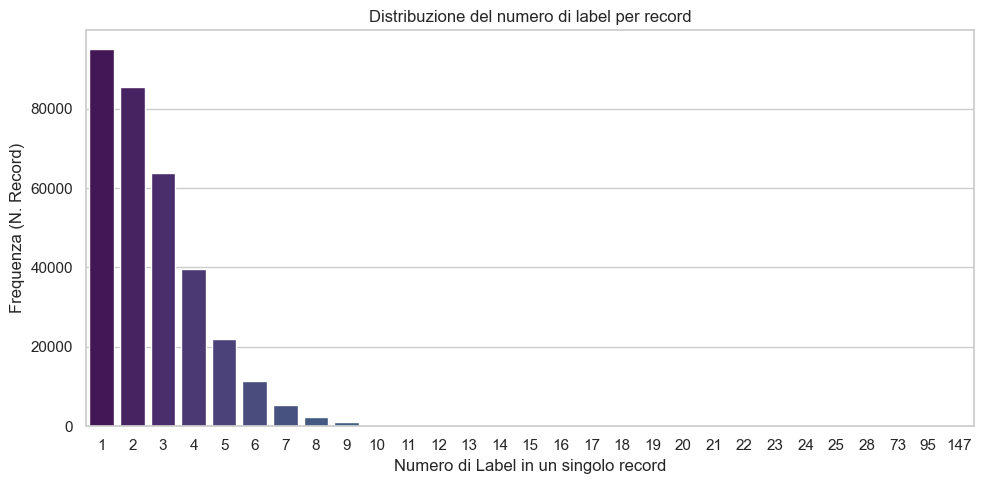

In [56]:
# 3. Distribuzione del Numero di Label per Record
plt.figure(figsize=(10, 5))
sns.countplot(data=df_multilabel, x='label_count', palette='viridis')
plt.title('Distribuzione del numero di label per record')
plt.xlabel('Numero di Label in un singolo record')
plt.ylabel('Frequenza (N. Record)')
plt.tight_layout()
plt.show()

Numero totale di singole label (uniche): 4616


/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_75010/1956865578.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_label_freq.head(60), x='count', y='label', palette='mako')


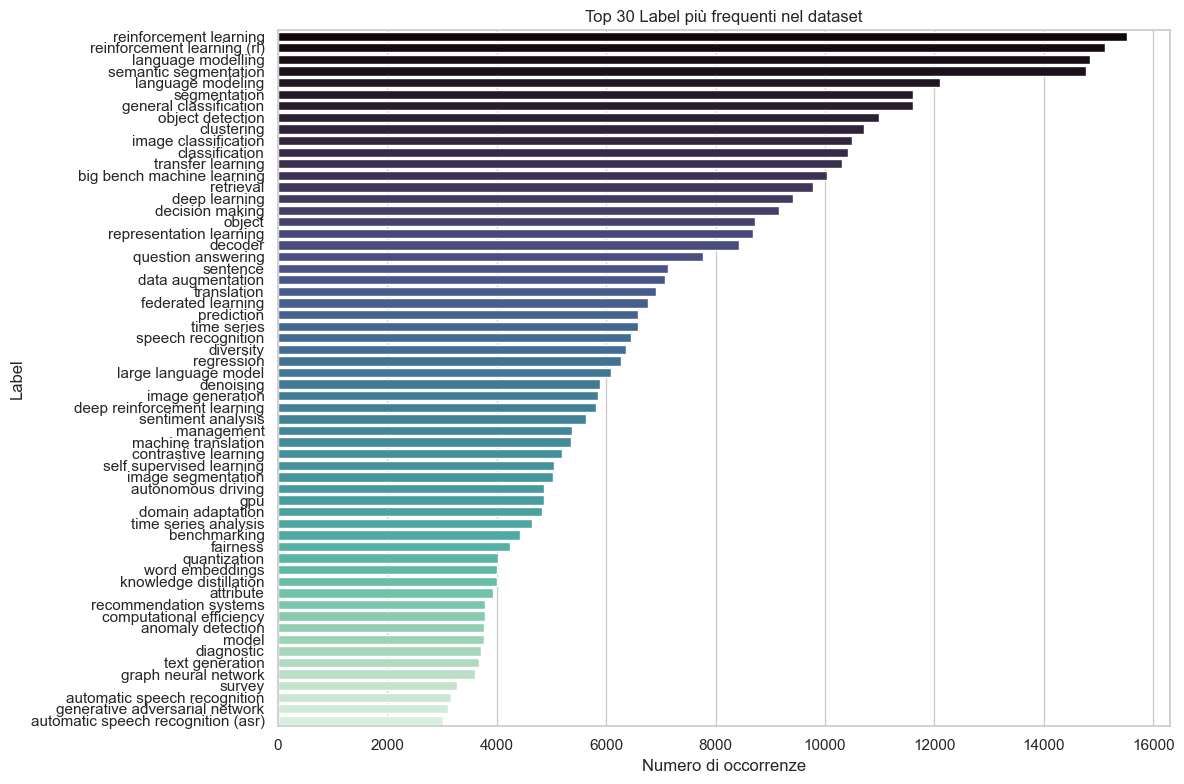

In [57]:
# 4. Frequenza delle Singole Label
all_labels = [label for labels in df_multilabel['labels_list'] for label in labels]
label_counts = Counter(all_labels)

print(f"Numero totale di singole label (uniche): {len(label_counts)}")

# Convertiamo in DataFrame per il plot
df_label_freq = pd.DataFrame.from_dict(label_counts, orient='index', columns=['count']).reset_index()
df_label_freq = df_label_freq.rename(columns={'index': 'label'}).sort_values('count', ascending=False)

plt.figure(figsize=(12, 8))
# Mostriamo le top 30 label
sns.barplot(data=df_label_freq.head(60), x='count', y='label', palette='mako')
plt.title('Top 30 Label più frequenti nel dataset')
plt.xlabel('Numero di occorrenze')
plt.ylabel('Label')
plt.tight_layout()
plt.show()

/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_75010/368078864.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_multilabel[df_multilabel['label_count'] <= 50], x='label_count', y='desc_length', palette='Set2')


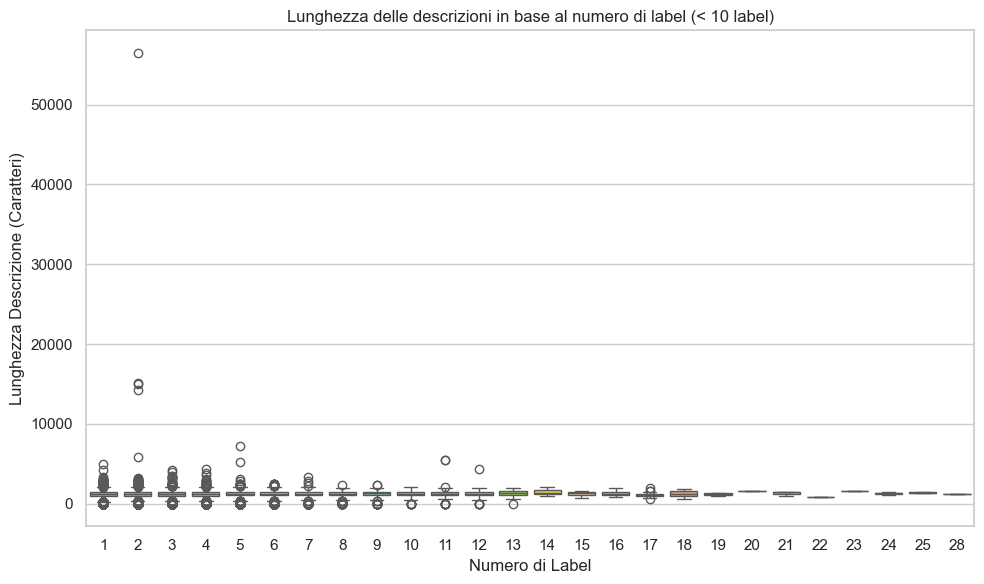

In [58]:
# 5. Lunghezza delle descrizioni basata sul numero di label
df_multilabel['desc_length'] = df_multilabel['description'].fillna('').astype(str).str.len()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_multilabel[df_multilabel['label_count'] <= 50], x='label_count', y='desc_length', palette='Set2')
plt.title('Lunghezza delle descrizioni in base al numero di label (< 10 label)')
plt.xlabel('Numero di Label')
plt.ylabel('Lunghezza Descrizione (Caratteri)')
plt.tight_layout()
plt.show()

In [59]:
# 6. Top 20 record con il maggior numero di label
print("Top 20 record con il maggior numero di label:")
display(df_multilabel.sort_values('label_count', ascending=False)[['description', 'labels', 'label_count']].head(20))

Top 20 record con il maggior numero di label:


,description,labels,label_count
140224,Language modelling provides a step towards int...,abstract algebra|anachronisms|analogical simil...,147
158081,The step function is one of the simplest and m...,10 shot image generation|16k|2d object detecti...,95
148563,We investigate the optimal model size and numb...,anachronisms|analogical similarity|analytic en...,73
188695,The use of NLP in the realm of financial techn...,causal judgment|common sense reasoning|date un...,28
103335,State-of-the-art computer vision systems are t...,action recognition|benchmarking|few shot image...,25
174659,Information overload is a major obstacle to sc...,anachronisms|bias detection|citation predictio...,25
40030,It is intuitive that NLP tasks for logographic...,chinese dependency parsing|chinese named entit...,24
22405,Subset selection from massive data with noised...,10 shot image generation|action recognition|co...,24
149412,Large language models have been shown to achie...,auto debugging|code generation|common sense re...,23
186605,"We report the development of GPT-4, a large-sc...",answerability prediction|arithmetic reasoning|...,22


# 7. Labels Mapping e Normalizzazione
Definiamo un dizionario per mappare le centinaia di label in circa 20-30 macro categorie e applichiamolo al dataset.

In [60]:
macro_mapping = {
    'Reinforcement Learning': [
        'reinforcement learning', 'reinforcement learning (rl)', 'deep reinforcement learning', 
        'q learning', 'multi agent reinforcement learning', 'imitation learning', 
        'continuous control', 'sequential decision making', 'offline reinforcement learning'
    ],
    'Natural Language Processing': [
        'language modelling', 'language modeling', 'large language model', 'sentence', 
        'natural language understanding', 'natural language inference', 'semantic textual similarity',
        'word embeddings', 'text classification', 'sentiment analysis', 'sentiment classification', 
        'named entity recognition', 'named entity recognition (ner)', 'ner', 'relation extraction',
        'prompt engineering', 'hallucination', 'in context learning'
    ],
    'Computer Vision': [
        'object detection', 'image classification', 'image segmentation', 'pose estimation',
        'instance segmentation', 'visual question answering', 'visual question answering (vqa)', 
        'object recognition', 'face recognition', '3d object detection', 'optical flow estimation',
        'scene understanding', 'image captioning', 'depth estimation', '3d reconstruction',
        'person re identification', 'object tracking', 'action recognition', 'activity recognition',
        'medical image segmentation', 'medical image analysis'
    ],
    'Classification & Regression': [
        'classification', 'general classification', 'binary classification', 
        'multi label classification', 'regression', 'node classification', 'graph classification'
    ],
    'Clustering & Segmentation': [
        'clustering', 'semantic segmentation', 'segmentation', 'video semantic segmentation'
    ],
    'Transfer Learning & Adaptation': [
        'transfer learning', 'domain adaptation', 'domain generalization', 
        'unsupervised domain adaptation', 'knowledge distillation'
    ],
    'Deep Learning Architectures': [
        'deep learning', 'representation learning', 'decoder', 'contrastive learning', 
        'self supervised learning', 'graph neural network', 'generative adversarial network', 
        'graph learning', 'neural architecture search', 'mixture of experts', 'mamba',
        'nerf', 'graph embedding'
    ],
    'Information Retrieval & QA': [
        'retrieval', 'question answering', 'information retrieval', 'retrieval augmented generation', 
        'rag', 'reading comprehension', 'image retrieval'
    ],
    'Translation': [
        'translation', 'machine translation', 'nmt', 'image to image translation'
    ],
    'Time Series & Forecasting': [
        'time series', 'time series analysis', 'time series forecasting', 'prediction'
    ],
    'GenAI & Synthesis': [
        'data augmentation', 'image generation', 'text generation', 'code generation', 
        'video generation', 'video summarization', 'speech synthesis', 'text to image generation', 'style transfer', 
        'text summarization', 'text to speech'
    ],
    'Agentic Systems & Multi-Agent': [
        'agentic systems', 'multi agent systems', 'multi agent reinforcement learning', 'autonomous agents', 
        'agent based modeling', 'agent based simulation', 'ai agent', 'agent swarm'
    ],
    'Speech & Audio': [
        'speech recognition', 'automatic speech recognition', 'automatic speech recognition (asr)', 
        'vocal bursts intensity prediction', 'emotion recognition'
    ],
    'Optimization & Efficiency': [
        'quantization', 'model compression', 'computational efficiency', 'parameter efficient fine tuning',
        'gpu', 'cpu', 'scheduling', 'bayesian optimization', 'combinatorial optimization', 'stochastic optimization'
    ],
    'Anomaly Detection & Security': [
        'anomaly detection', 'adversarial attack', 'adversarial robustness', 'privacy preserving',
        'misinformation'
    ],
    'Ethics, Fairness & Explainability': [
        'fairness', 'explainable artificial intelligence', 'explainable artificial intelligence (xai)',
        'diversity', 'bias', 'diagnostic'
    ],
    'Decision Making & Reasoning': [
        'decision making', 'math', 'knowledge graphs', 'causal inference'
    ],
    'Few-Shot & Meta Learning': [
        'few shot learning', 'meta learning', 'zero shot learning', 'active learning', 
        'continual learning', 'incremental learning', 'multi task learning'
    ],
    'Autonomous Systems': [
        'autonomous driving', 'autonomous vehicles', 'navigate', 'robotics', 'robotic manipulation', 'robotic grasping', 'robotic control',
        'visual servoing', 'simultaneous localization and mapping', 'slam', 'robotic navigation', 'llm controlled drone', 'agentic unmanned vehicle'
    ]
}

# Funzione per invertire il dizionario {sottocategoria: MacroCategoria}
reverse_mapping = {}
for macro, sub_labels in macro_mapping.items():
    for sub in sub_labels:
        reverse_mapping[sub.lower()] = macro

def map_labels(label_list):
    mapped = set()
    for lbl in label_list:
        lbl_lower = lbl.lower()
        if lbl_lower in reverse_mapping:
            mapped.add(reverse_mapping[lbl_lower])
        else:
            # Se la label non è tra le top specificate, la mettiamo in "Other AI/ML Techniques"
            mapped.add('Other AI/ML Techniques')
    return list(mapped)

df_multilabel['mapped_labels'] = df_multilabel['labels_list'].apply(map_labels)
df_multilabel['mapped_label_count'] = df_multilabel['mapped_labels'].apply(len)

print("Esempio di mapping:")
display(df_multilabel[['labels_list', 'mapped_labels']].head(10))

Esempio di mapping:


,labels_list,mapped_labels
0,"[model, open ended question answering]",[Other AI/ML Techniques]
1,[big bench machine learning],[Other AI/ML Techniques]
2,"[self supervised learning, surgical phase reco...","[Deep Learning Architectures, Other AI/ML Tech..."
3,[regression],[Classification & Regression]
4,[big bench machine learning],[Other AI/ML Techniques]
5,"[dimensionality reduction, retrieval]","[Information Retrieval & QA, Other AI/ML Techn..."
6,"[anatomy, image segmentation, segmentation, se...","[Computer Vision, Other AI/ML Techniques, Clus..."
7,"[mixture of experts, relational reasoning, vis...","[Deep Learning Architectures, Other AI/ML Tech..."
8,[video summarization],[GenAI & Synthesis]
9,[3d geometry],[Other AI/ML Techniques]


Numero totale di macro-categorie (uniche): 20


/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_75010/458756513.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_mapped_freq, x='count', y='macro_label', palette='mako')


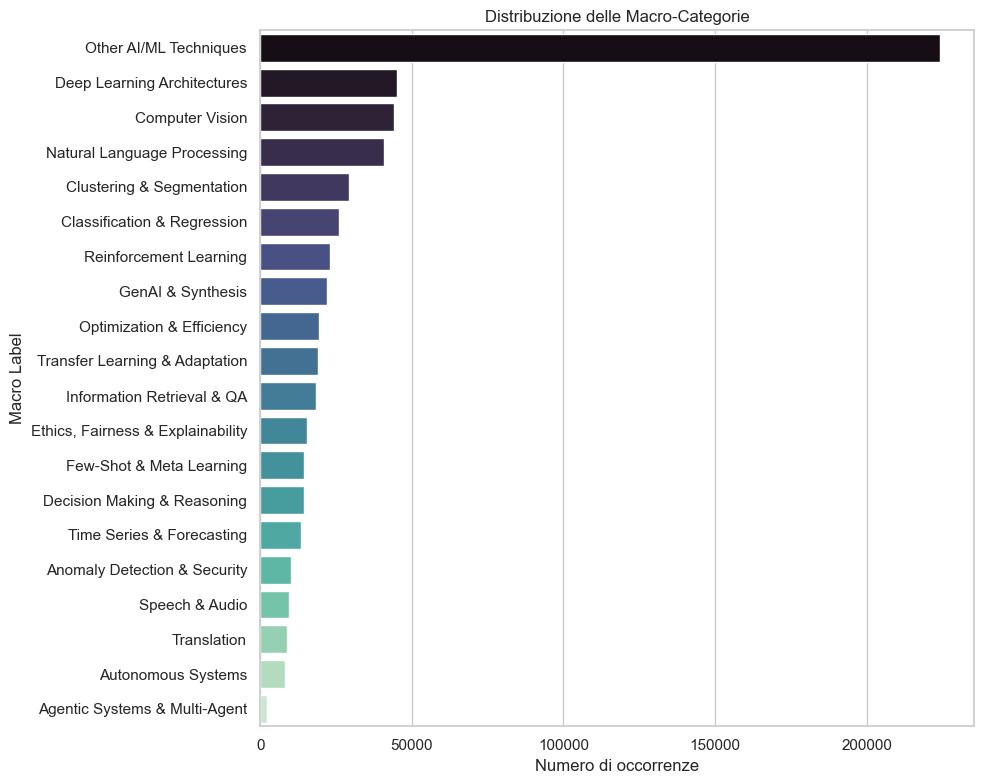

In [61]:
# 8. Analisi delle nuove Label Mappate
all_mapped_labels = [label for labels in df_multilabel['mapped_labels'] for label in labels]
mapped_label_counts = Counter(all_mapped_labels)

print(f"Numero totale di macro-categorie (uniche): {len(mapped_label_counts)}")

# Convertiamo in DataFrame per il plot
df_mapped_freq = pd.DataFrame.from_dict(mapped_label_counts, orient='index', columns=['count']).reset_index()
df_mapped_freq = df_mapped_freq.rename(columns={'index': 'macro_label'}).sort_values('count', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=df_mapped_freq, x='count', y='macro_label', palette='mako')
plt.title('Distribuzione delle Macro-Categorie')
plt.xlabel('Numero di occorrenze')
plt.ylabel('Macro Label')
plt.tight_layout()
plt.show()

In [62]:
# 9. Salvataggio del nuovo Dataset Normalizzato
# Riassembliamo le liste mappate in una stringa separata da '|'
df_multilabel['final_labels'] = df_multilabel['mapped_labels'].apply(lambda x: '|'.join(x))

df_mapped_export = df_multilabel.drop(columns=['labels_list', 'label_count', 'desc_length', 'mapped_labels', 'mapped_label_count'])

output_path = '../data/processed/pwc_ai_multilabel_mapped.csv'
df_mapped_export.to_csv(output_path, index=False)
print(f"Nuovo dataset salvato correttamente in: {output_path}")

print(f"\nPrime righe del nuovo dataset salvato:\n")
display(df_mapped_export.head())

Nuovo dataset salvato correttamente in: ../data/processed/pwc_ai_multilabel_mapped.csv

Prime righe del nuovo dataset salvato:



,description,labels,final_labels
0,Can evolving networks be inferred and modeled ...,model|open ended question answering,Other AI/ML Techniques
1,This paper investigates the automated recognit...,big bench machine learning,Other AI/ML Techniques
2,In order to provide the right type of assistan...,self supervised learning|surgical phase recogn...,Deep Learning Architectures|Other AI/ML Techni...
3,Many estimators of the average effect of a tre...,regression,Classification & Regression
4,A unified approach to explain the output of an...,big bench machine learning,Other AI/ML Techniques
